# Reconstruction error per population (axis-100-3000)

Per-pixel reconstruction error of the five real-only baselines on this axis, compared between training pixels, withheld test pixels of the training images and whole held-out images. The question is whether reconstruction quality degrades from seen pixels to unseen pixels to unseen images.

## Introduction

Every metric is computed per pixel from the decoded input $X$ and the reconstruction $\hat X$ of one model.
The training objective is $W_1$; the complementary metrics describe different failure modes: `mse` and `mae`
are intensity errors per bin, `cosine_similarity` and `spectral_angle` compare spectral shape independently
of scale, and `tic_error` is the deviation of the reconstructed total ion current (zero for a TIC-normalized
decoder up to numerical error).

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

        * `test_extended` pixels were drawn to support rare classes; their spectra over-represent rare molecules and
          are not a random sample of the training images. Their reconstruction error is reported but not used as a
          generic test estimate.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "reconstruction_global"
AXIS = "axis-100-3000"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

Analysis: reconstruction_global | axis: axis-100-3000 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 100-3000 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

The `inference` cache level evaluates every model on every population in bounded batches and stores the
per-pixel metrics; `reconstruction_global` summarises them (distribution statistics, 51 quantiles, per-image
means, differences of population means) and draws a fixed seeded pixel sample (2000 pixels per population,
identical for every model) for the distribution figures.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis reconstruction_global > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Reconstruction error summary per population

### Methodology

#### Theoretical

For every model $r$, population $P$ and metric $f$ the mean $\bar f_{r,P} = |P|^{-1} \sum_{x \in P} f(x,
\hat x)$ is computed over every pixel of the population. The table reports the mean and the standard
deviation of $\bar f_{r,P}$ over the five repetitions.

#### Implementation

`summary` holds mean, median, 10/90/99 % quantiles per model, population and metric over all pixels.

#### Figure descriptions

No figure; rows = metrics, columns = populations (mean and SD over repetitions).

In [3]:
summary = table('summary')
statistics = summary.groupby(['metric', 'population'])['mean'].agg(['mean', 'std']).unstack('population')
display(statistics.reindex(columns=POPULATIONS, level='population'))

mean                                                 std                                        
population              train        test test_extended heldout_image       train        test test_extended heldout_image
metric                                                                                                                   
cosine_similarity  4.5774e-01  4.5749e-01    3.7152e-01    4.8984e-01  2.2686e-02  2.2622e-02    1.4293e-02    2.9870e-02
mae                2.3624e-04  2.3621e-04    2.4750e-04    2.5694e-04  3.3826e-06  3.3700e-06    3.5353e-06    4.2603e-06
masserstein        3.9791e+00  3.9877e+00    5.4128e+00    4.4675e+00  1.5847e-01  1.5520e-01    1.2591e-01    2.9029e-01
mse                6.7560e-06  6.7933e-06    3.3941e-06    3.6192e-06  2.0580e-07  2.0680e-07    5.1467e-08    1.4027e-07
spectral_angle     1.0942e+00  1.0945e+00    1.1889e+00    1.0582e+00  2.5881e-02  2.5802e-02    1.5782e-02    3.4793e-02
tic_error          4.7242e-08  4.7662e-08    4.6858e-08    7.6286e-08  1.9161e-08  1.9422e-08    1.6833e-08    3.7027e-08

### Remarks

### Notes

## Distribution of pixel-level reconstruction error

### Methodology

#### Theoretical

Means hide tails: two populations with equal mean $W_1$ can differ in the fraction of badly reconstructed
pixels. The full pixel distribution of every metric is compared across populations.

#### Implementation

Violins use the 2000 sampled pixels of every population pooled over the five repetitions (10 000 values per
violin); the sample rows are identical for every model. Repetition means over *all* pixels are overlaid.

#### Figure descriptions

One panel per metric; x = population, y = metric value per pixel. Violin = pooled pixel distribution; small
dots = 200 evenly spaced pixels of that distribution; black diamonds = mean over all pixels of one repetition.
Lower is better except for `cosine_similarity` (higher is better).

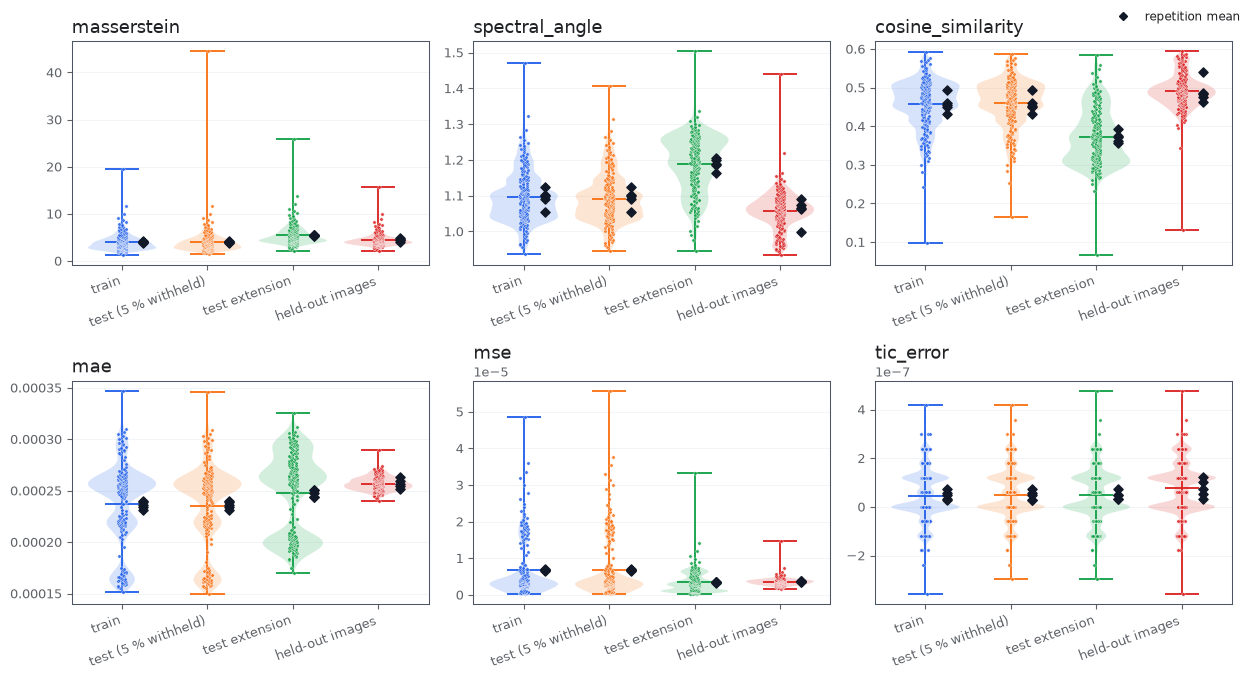

In [4]:
pixels = table('pixel_sample')
figures.population_distributions(pixels, summary, ['masserstein', 'spectral_angle', 'cosine_similarity', 'mae', 'mse', 'tic_error'], POPULATIONS, theme=theme);

### Remarks

- `test_extended` is again the hardest population (W1 5.41 vs 3.99 on test).
- Held-out images have higher W1 (4.47) than test but a lighter extreme tail (q99 8.8 vs 9.8) and higher cosine (0.49 vs 0.46).

### Notes

## Quantile functions of the Masserstein cost

### Methodology

#### Theoretical

The empirical quantile function $q \mapsto F^{-1}_{r,P}(q)$ of $W_1$ shows at which part of the distribution
two populations differ: a vertical offset over all $q$ is a global shift, a divergence only near $q = 1$ is a
tail effect.

#### Implementation

`quantiles` holds 51 equally spaced quantile levels per model, population and metric over all pixels.

#### Figure descriptions

x = quantile level, y = $W_1$ (log scale); one line per repetition, colour = population.

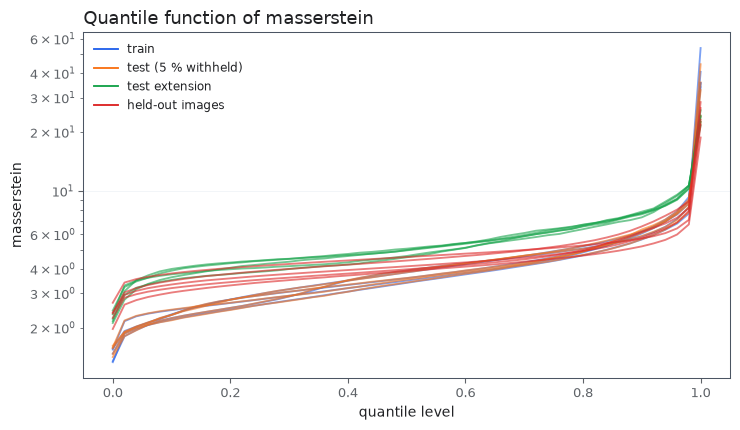

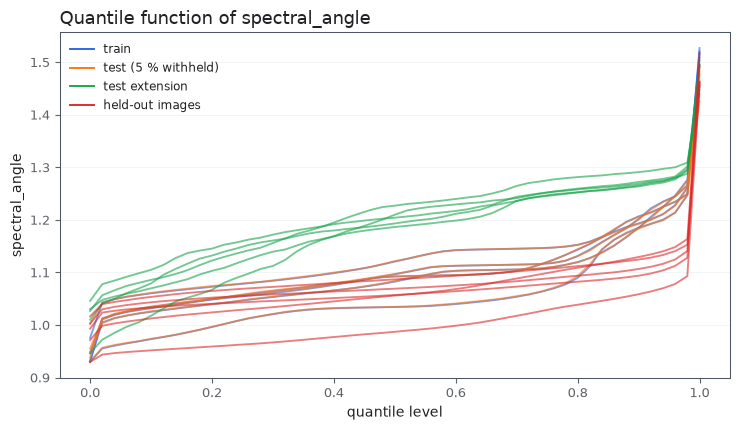

In [5]:
quantiles = table('quantiles')
figures.quantile_curves(quantiles, metric='masserstein', populations=POPULATIONS, log=True, theme=theme);
figures.quantile_curves(quantiles, metric='spectral_angle', populations=POPULATIONS, theme=theme);

### Remarks

- The held-out quantile function lies above test up to about the 90 % level (median 4.20 vs 3.66) and below it in the upper tail (q99 8.8 vs 9.8): the held-out shift affects typical pixels, not the tail.

### Notes

## Reconstruction error per source image

### Methodology

#### Theoretical

Population means average over images of very different size and composition. The mean $W_1$ per source image
separates image-specific difficulty from the effect of being withheld.

#### Implementation

`image_breakdown` holds the mean per model, population, image and metric.

#### Figure descriptions

x = source image (ordered by the mean training error), y = mean $W_1$ of the image's pixels; colour =
population, one point per repetition, bar = mean over repetitions. The held-out images appear only in the
held-out population.

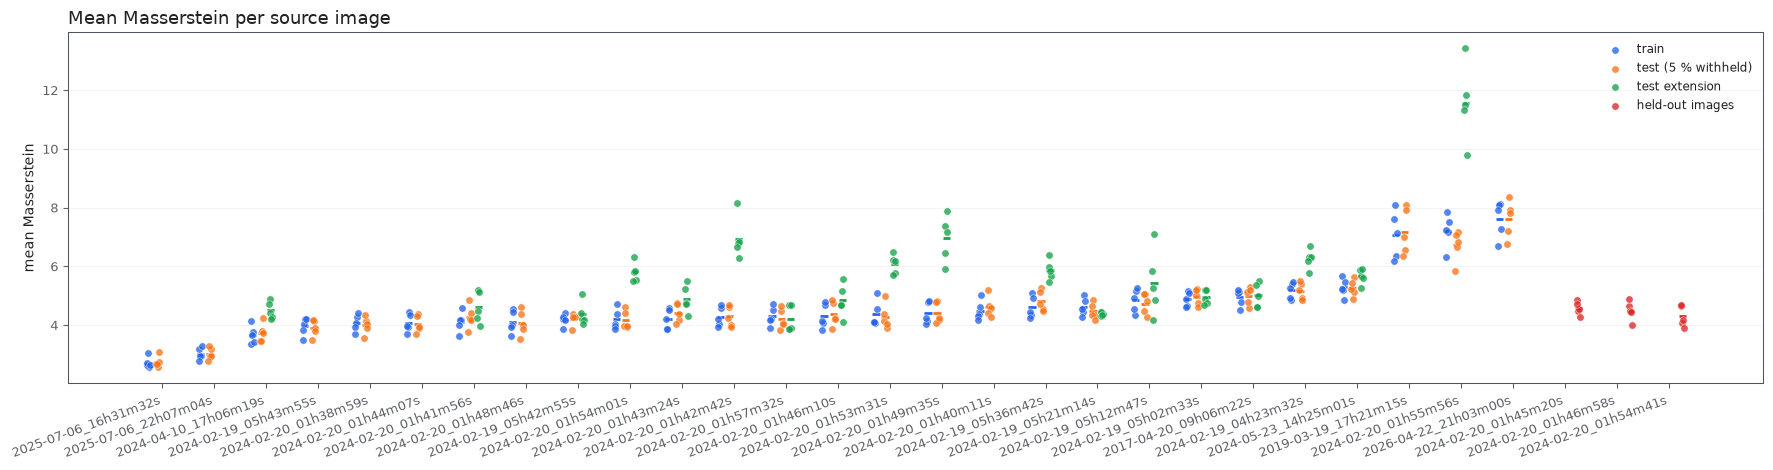

In [6]:
images = table('image_breakdown')
masserstein = images[images.metric == 'masserstein']
order = list(masserstein[masserstein.population == 'train'].groupby('dataset_id')['mean'].mean().sort_values().index) + DATASETS
figure, ax = plt.subplots(figsize=(18, 4.8), dpi=theme.figure_dpi)
figures.repetition_points(masserstein, value='mean', group='dataset_id', hue='population', order=order, hue_order=POPULATIONS, colors=POPULATION_COLORS, ylabel='mean Masserstein', title='Mean Masserstein per source image', ax=ax, theme=theme);

### Remarks

- All three held-out images (4.3-4.6) lie in the upper part of the training-image range (2.7-7.6).

### Notes

## Generalization gaps of reconstruction

### Methodology

#### Theoretical

For every repetition the differences $\bar f_{r,\mathrm{test}} - \bar f_{r,\mathrm{train}}$ (new pixels of
seen images) and $\bar f_{r,\mathrm{heldout}} - \bar f_{r,\mathrm{test}}$ (new images) are computed. The
repetition is the unit: the spread over five repetitions indicates whether a gap is systematic.

#### Implementation

`gaps` holds the population means per model and metric and their differences.

#### Figure descriptions

x = metric, y = gap; colour = gap type, one point per repetition; the dashed line marks no gap.

mean                                                     std                                     
quantity          heldout_minus_test heldout_minus_train test_minus_train heldout_minus_test heldout_minus_train test_minus_train
metric                                                                                                                           
cosine_similarity         3.2351e-02          3.2092e-02      -2.5865e-04         9.0082e-03          8.9455e-03       9.4257e-05
mae                       2.0723e-05          2.0701e-05      -2.2183e-08         1.3724e-06          1.3612e-06       1.6738e-08
masserstein               4.7979e-01          4.8837e-01       8.5761e-03         1.6644e-01          1.6223e-01       6.9121e-03
mse                      -3.1741e-06         -3.1369e-06       3.7263e-08         7.4976e-08          7.4168e-08       1.0547e-09
spectral_angle           -3.6256e-02         -3.5946e-02       3.0955e-04         1.0892e-02          1.0814e-02       1.1203e-04
tic_error                 2.8624e-08          2.9045e-08       4.2084e-10         1.8517e-08          1.8645e-08       1.3193e-09

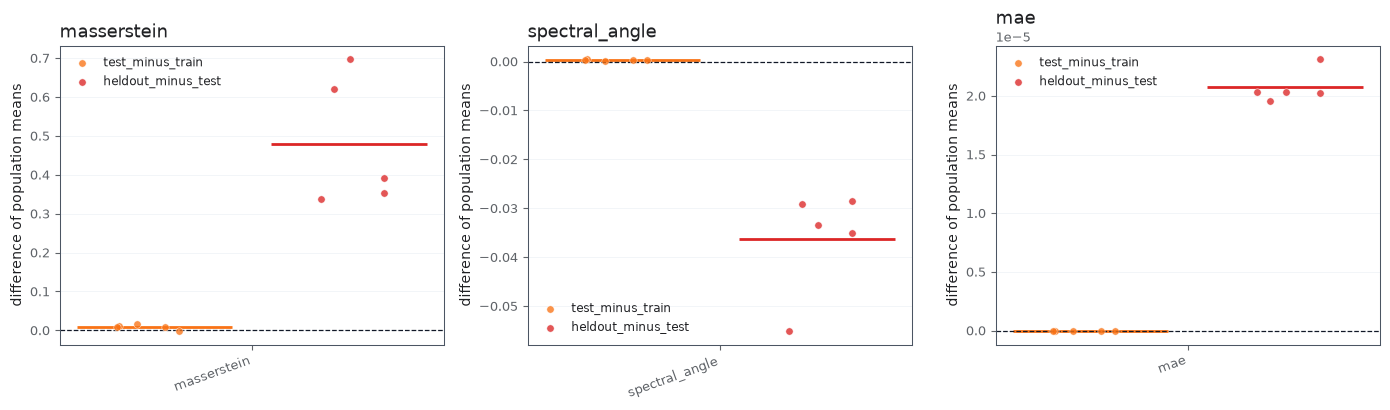

In [7]:
gaps = table('gaps')
display(mean_sd(gaps, ['metric'], ['test_minus_train', 'heldout_minus_test', 'heldout_minus_train']))
long = gaps.melt(id_vars=['metric', 'repetition'], value_vars=['test_minus_train', 'heldout_minus_test'], var_name='gap', value_name='difference')
long = long[long.metric.isin(['masserstein', 'spectral_angle', 'mae'])]
figure, axes = plt.subplots(1, 3, figsize=(14, 4.2), dpi=theme.figure_dpi)
for ax, metric in zip(axes, ['masserstein', 'spectral_angle', 'mae']):
    figures.repetition_points(long[long.metric == metric], value='difference', group='metric', hue='gap', order=[metric], hue_order=['test_minus_train', 'heldout_minus_test'], colors={'test_minus_train': POPULATION_COLORS['test'], 'heldout_minus_test': POPULATION_COLORS['heldout_image']}, ylabel='difference of population means', title=metric, reference=0.0, ax=ax, theme=theme)
figure.tight_layout()

### Remarks

- held-out - test W1 = +0.48 +/- 0.17, positive in all five repetitions (min +0.34); test - train = +0.009.
- Spectral angle and cosine still improve on held-out images; the W1 increase is therefore not a worse local shape (see `part_1_02`).

### Notes

## Results / Summary

### LLM

- **Observed:** W1 is 3.98 (train), 3.99 (test) and 4.47 (held-out); the held-out increase is systematic (5/5 repetitions) while spectral angle and cosine are better on held-out images.
- **Interpretation (supported by `part_1_02`):** the W1 increase comes from a different distribution of intensity over m/z in the held-out images (much less mass in 100-200 m/z), which lengthens transport paths, not from worse local reconstruction.
- **Caveat:** absolute W1 values are not comparable with the 200-900 axis (different transport range and TIC normalization).

### Person